# Final Project

#### Imports

In [11]:
from platform import android_ver

import torch
from numpy.ma.extras import average
from torch.utils.data import Dataset, dataloader
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import string
import time

#### Loading Dataset
b) Download the EMNIST dataset. Note that it contains 6 variants, so called splits, which differ in size and contents. For the first half of the project, you should be using the ‘letters’ split. After loading the dataset, plot a random selection of image samples and the corresponding labels (similar to Figure 1.).

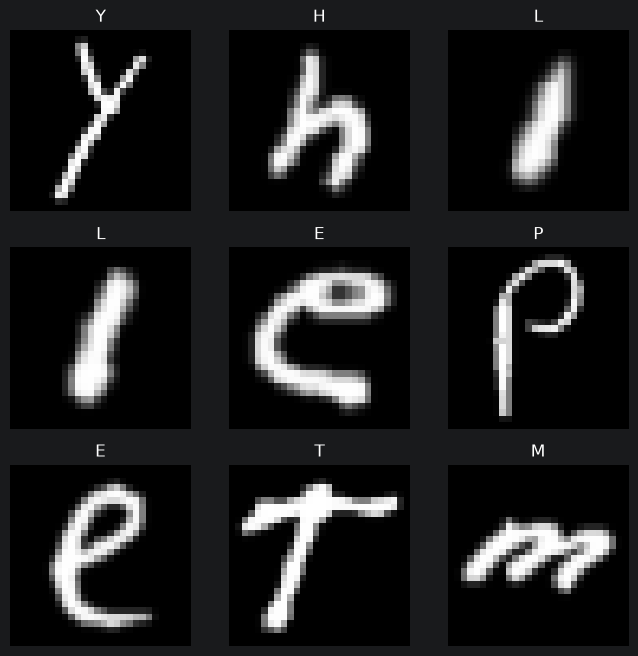

In [12]:
training_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

letters = ["N/A"] + list(string.ascii_uppercase)

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(letters[label])
    plt.axis("off")
    plt.imshow(img.squeeze().T, cmap="gray")
plt.show()

#### Basic learning functionality
c) Implement a program that defines the simple CNN model depicted in see Figure 2. and trains letter classification on the loaded dataset from step b). Implement two functions that use the given model and respective dataset for training and testing. Using cross entropy loss can be a convenient loss function, since it does not require normalized input. In addition, your program should visualize (plot) the training loss and record the total training time.

##### Create Data Loader

In [13]:
batch_size = 64

training_loader = DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
)


##### Define CNN

In [14]:
model = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Flatten(),
    torch.nn.Linear(in_features= 8 * 14 * 14, out_features=26),
)

##### Loss Function and Optimizer

In [15]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

##### Training Function

In [16]:
def train(model, training_loader, criterion, optimizer):
    model.train()

    running_loss = 0
    batch_losses = []

    for images, labels in training_loader:
        labels = labels - 1

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        batch_losses.append(loss.item())

    average_loss = running_loss / len(training_loader)

    return average_loss, batch_losses

##### Test Function

In [17]:
def test(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            labels = labels - 1

            outputs = model(images)
            predictions = outputs.argmax(dim = 1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy

##### Training Loop

In [18]:
epochs = 5
loss_history = []

start_time = time.time()

for epoch in range(epochs):
    avg_loss, batch_losses = train(
        model,
        training_loader,
        criterion,
        optimizer
    )

    loss_history.append(batch_losses)

    accuracy = test(model, test_loader)

    print(
        f"Epoch {epoch+1}{epochs}"
        f"Loss {avg_loss:.4f}"
        f"Accuracy {accuracy:.2f}%"
    )

training_time = time.time() - start_time

print(f"\nTraining time: {training_time:.2f} seconds")

/home/thery.johanna/Desktop/Studium/12. Semester/IAOR_SS26/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:422: UserWarning: Found GPU0 NVIDIA GeForce GTX 1050 which is of compute capability (CC) 6.1.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Your installed torch==2.13.0+cu130 does not include kernels for this GPU. Reinstall the same version against a CUDA build that does, e.g.:
  For CUDA 12.6 use pip install torch==2.13.0 --index-url https://download.pytorch.org/whl/cu126
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/thery.johanna/Desktop/Studium/12. Semester/IAOR_SS26/.venv/lib/python3.14/site-pac

Epoch 15Loss 0.9138Accuracy 81.59%
Epoch 25Loss 0.5459Accuracy 85.42%
Epoch 35Loss 0.4577Accuracy 86.12%
Epoch 45Loss 0.4112Accuracy 87.20%
Epoch 55Loss 0.3850Accuracy 87.78%

Training time: 167.77 seconds


##### Training Loss Plot

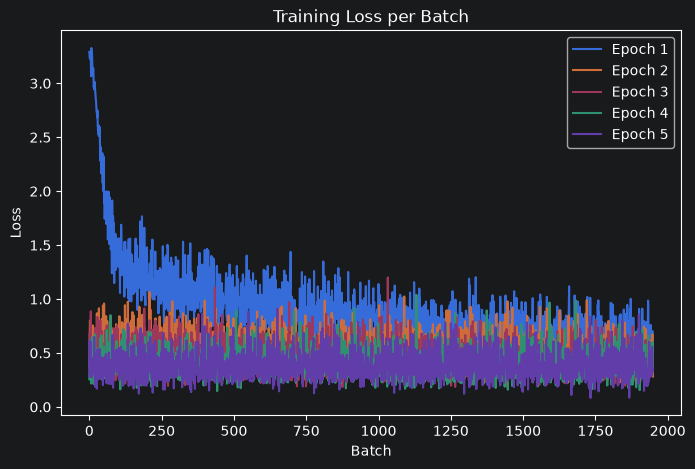

In [19]:
plt.figure(figsize=(8, 5))

for epoch, losses in enumerate(loss_history):
    plt.plot(losses, label=f"Epoch {epoch+1}")

plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Training Loss per Batch")
plt.legend()

plt.show()